In [1]:
from ReadOriginalData import *

### Características previas

In [2]:
#path: directory
#dst_path: directory of figures to be saved
#start_secction: section str where user wants to start, default -> A01
#raw: boolean to indicate to plot normal plot, or raw to detect anomalies
    
path = "./Data/corrected_sections/"
dst_path = "./plots/"
raw = True

## Plot occupation of sections over years

In [40]:
directory = os.listdir(path = path) # Get the directory
sections = sorted(os.listdir(path)) # Sorted sections

In [52]:
sections=['A01']

Plotting raw TS diagram of section A01....
Processing file: 1991_06MT18_1_ctd.nc
Processing file: 1994_06MT30_3_ctd.nc
Processing file: 1995_18HU95011_1_ctd.nc
Processing file: 2000_64PE20000926_ctd.nc
Processing file: 2014_35PK20140515_ctd.nc
Processing file: 2015_5_58GS20150410_ctd.nc


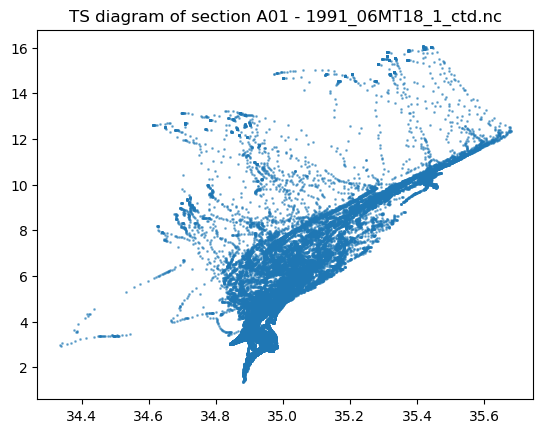

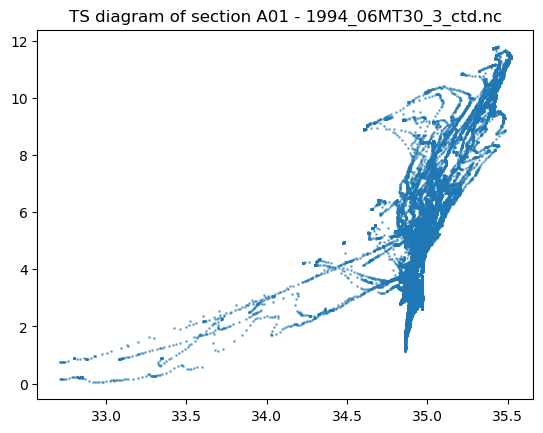

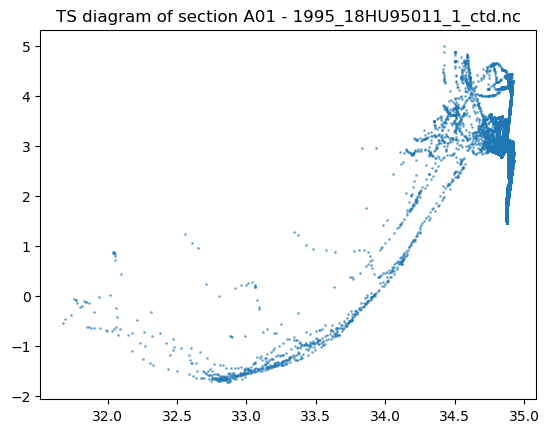

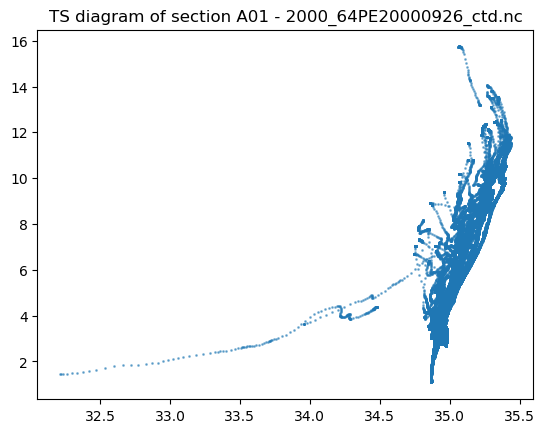

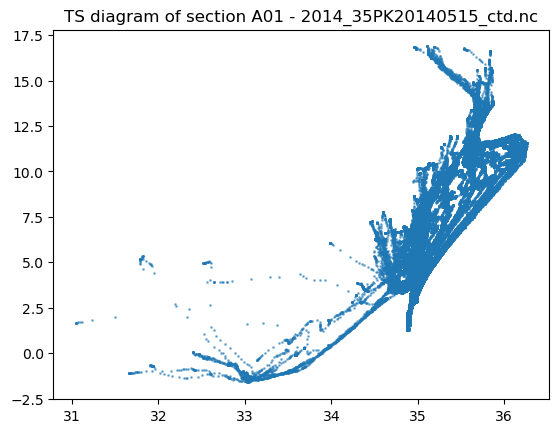

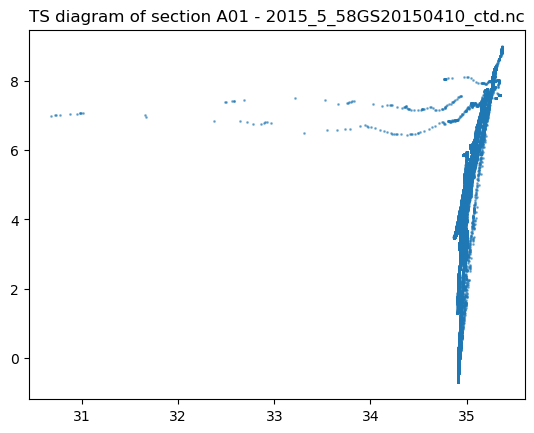

In [54]:
for section in sections:
    print(f"Plotting TS diagram of section {section}...." if raw == False else f"Plotting raw TS diagram of section {section}....")

    # Iterate for every file
    
    for f in sorted(os.listdir(path + section + "/")):
        if f == ".DS_Store":
            continue        
        print(f"Processing file: {f}")        
        t = 0
        ds = xr.open_dataset(path + section + "/" + f)
        fig, ax = plt.subplots()
        for temperature, salinity in zip(["ctd_temperature", "ctd_temperature_unk"], ["ctd_salinity", "ctd_salinity_unk", "ctd_salinity_68"]):
            if temperature in ds.data_vars and t == 0:
                t = ds[temperature]
            if salinity in ds.data_vars:
                sal = ds[salinity]

        plt.scatter(sal, t, s = 0.4 if raw == False else 1, alpha = 0.2 if raw == False else 0.5,)
        plt.title(f"TS diagram of section {section} - {f}")

